# DB Library Analysis

## Imports

In [1]:
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, ttest_ind


## Configuration

Shared across all three figures: the input CSV, the five characterized binders (DB1–DB5) and their structure-name → label → color mappings. Per-figure manual label-positioning dictionaries stay inline in their respective figure cells.

In [5]:
DATA_FILE = 'library_data.csv'

# ── Characterized binders to highlight in the violin and histogram plots ────
TARGET_STRUCTURES = [
    "S10_4FXE_3312_13_95_0001_0001_m_4FXE_14395_200_248_0001_0001_m_combined_0_dldesign_0_af2pred",
    "S9_4FXE_19800_130_232_0001_0001_m_4FXE_14423_1003_1126_0001_0001_m_combined_0_dldesign_4_af2pred",
    "S11_4FXE_1226_54_24_0001_0001_m_4FXE_2307_203_251_0001_0001_m_combined_3_dldesign_1_af2pred",
    "S6_4FXE_12201_273_348_0001_0001_m_4FXE_10940_224_349_0001_0001_m_combined_0_dldesign_1_af2pred",
    "S9_4FXE_22415_5_75_0001_0001_m_4FXE_14395_200_248_0001_0001_m_combined_0_dldesign_1_af2pred",
]
TARGET_LABELS = ["DB1", "DB2", "DB3", "DB4", "DB5"]
TARGET_COLORS = {
    "DB1": "lightblue",
    "DB2": "orange",
    "DB3": "lightgreen",
    "DB4": "plum",
    "DB5": "tomato",
}


## Helpers for naming and reseq label

In [10]:
def normalize_for_matching(name):
    """Strip `_reseq{N}` and `_af2pred` suffixes for cross-prediction matching."""
    if pd.isna(name):
        return ''
    name = str(name)
    name = re.sub(r'_reseq\d+$', '', name)
    name = re.sub(r'_af2pred$',   '', name)
    return name


def is_resequenced(name):
    """True if structure name carries a `reseq` indicator."""
    if pd.isna(name):
        return False
    return 'reseq' in str(name).lower()


## Load data

In [11]:
df = pd.read_csv(DATA_FILE, low_memory=False)
print(f"Loaded {len(df)} rows from {DATA_FILE}")

enriched_df = df[df['Sequence_ID'].notna()].copy()
enriched_df['normalized_name'] = enriched_df['new_structure_name'].apply(normalize_for_matching)
enriched_df['is_resequenced']  = enriched_df['new_structure_name'].apply(is_resequenced)

print(f"  Structures with enrichment data: {len(enriched_df)}")
print(f"  Resequenced: {enriched_df['is_resequenced'].sum()}")
print(f"  Original:    {(~enriched_df['is_resequenced']).sum()}")


Loaded 1402 rows from library_data.csv
  Structures with enrichment data: 1397
  Resequenced: 944
  Original:    453


## 1. Metric correlation matrix


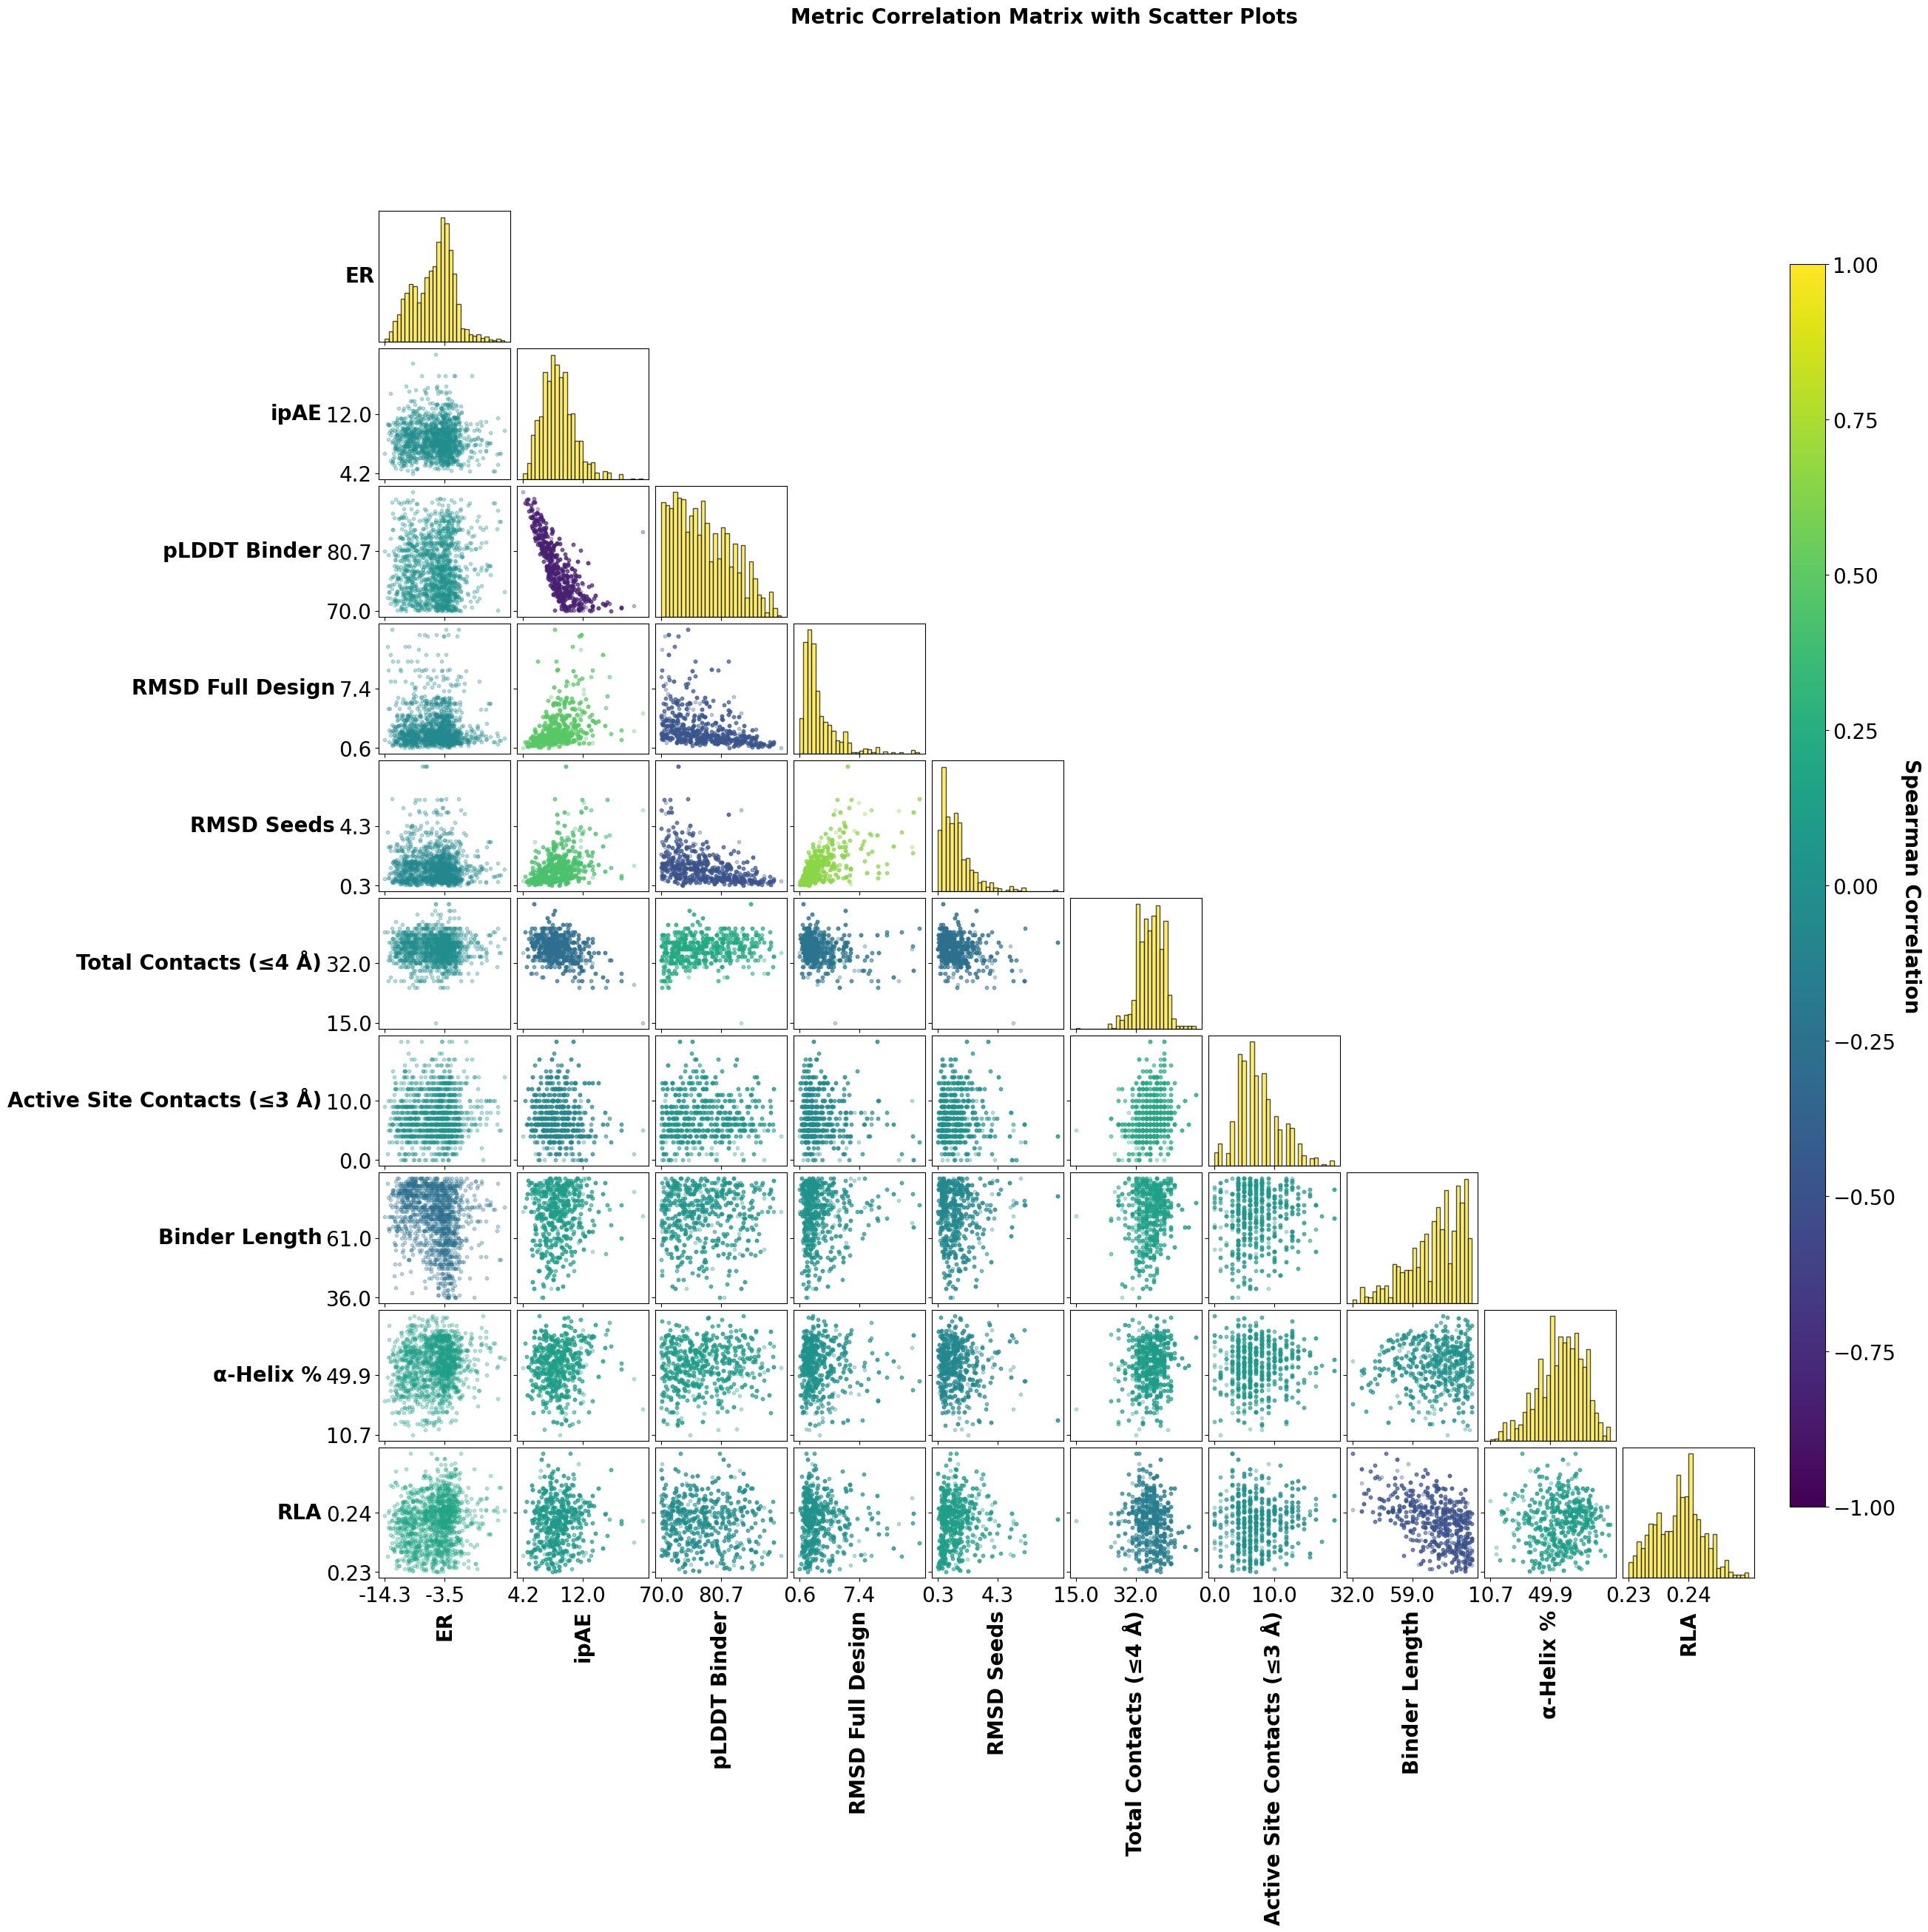

✓ metric_by_metric_af2_2.png


In [12]:
METRICS = [
    'Log2_Enrichment_S2',
    'pae_interaction',
    'plddt_binder',
    'RMSD_All_ChainA',
    'RMSD_NonDesignable',
    'total_contacts',
    'specific_contacts',
    'Protein_Length',
    'Alpha_Helix_Percent',
    'RLA_score',
]
METRIC_LABELS = [
    'ER',
    'ipAE',
    'pLDDT Binder',
    'RMSD Full Design',
    'RMSD Seeds',
    'Total Contacts (≤4 Å)',
    'Active Site Contacts (≤3 Å)',
    'Binder Length',
    'α-Helix %',
    'RLA',
]

n_metrics = len(METRICS)
fig, axes = plt.subplots(n_metrics, n_metrics, figsize=(24, 24))
fig.subplots_adjust(hspace=0.05, wspace=0.05)

cmap = plt.cm.viridis
norm = plt.Normalize(vmin=-1, vmax=1)
RLA_IDX = METRICS.index('RLA_score')   # only metric formatted to 2 decimals

for i in range(n_metrics):
    for j in range(n_metrics):
        ax = axes[i, j]

        if j > i:                     # upper triangle hidden
            ax.axis('off')
            continue

        x_data = df[METRICS[j]].dropna()
        y_data = df[METRICS[i]].dropna()
        common_idx = x_data.index.intersection(y_data.index)
        x_plot = x_data.loc[common_idx]
        y_plot = y_data.loc[common_idx]

        if len(x_plot) > 0:
            x_decimals = 2 if j == RLA_IDX else 1
            y_decimals = 2 if i == RLA_IDX else 1

            if i == j:                # diagonal: histogram
                color = cmap(norm(1.0))
                ax.hist(x_plot, bins=30, color=color, alpha=0.7, edgecolor='black')
                ax.set_yticks([])
                x_min, x_max = x_plot.min(), x_plot.max()
                x_ticks = [x_min, (x_min + x_max) / 2]
                ax.set_xticks(x_ticks)
                ax.set_xticklabels([f'{t:.{x_decimals}f}' for t in x_ticks])
                ax.tick_params(axis='x', labelsize=20)
            else:                     # lower triangle: scatter colored by Spearman ρ
                corr, _ = spearmanr(x_plot, y_plot)
                color = cmap(norm(corr))
                ax.scatter(x_plot, y_plot, alpha=0.3, s=10, c=[color], rasterized=True)

                x_min, x_max = x_plot.min(), x_plot.max()
                y_min, y_max = y_plot.min(), y_plot.max()
                x_ticks = [x_min, (x_min + x_max) / 2]
                y_ticks = [y_min, (y_min + y_max) / 2]
                ax.set_xticks(x_ticks); ax.set_yticks(y_ticks)
                ax.set_xticklabels([f'{t:.{x_decimals}f}' for t in x_ticks])
                ax.set_yticklabels([f'{t:.{y_decimals}f}' for t in y_ticks])
                ax.tick_params(axis='x', labelsize=20)
                ax.tick_params(axis='y', labelsize=20)

        # Edge labels only
        if i == n_metrics - 1:
            ax.set_xlabel(METRIC_LABELS[j], fontsize=20, fontweight='bold',
                          rotation=90, va='top')
        else:
            ax.set_xticklabels([])

        if j == 0:
            ax.set_ylabel(METRIC_LABELS[i], fontsize=20, fontweight='bold',
                          rotation=0, ha='right', va='center')
        else:
            ax.set_yticklabels([])

# Shared colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(sm, cax=cbar_ax)
cbar.set_label('Spearman Correlation', rotation=270, labelpad=25,
               fontsize=20, fontweight='bold')
cbar.ax.tick_params(labelsize=20)

plt.suptitle('Metric Correlation Matrix with Scatter Plots',
             fontsize=20, fontweight='bold', y=0.995)
plt.savefig('metric_by_metric_af2_2.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ metric_by_metric_af2_2.png")


## 2. Violin plots with DB1–DB5

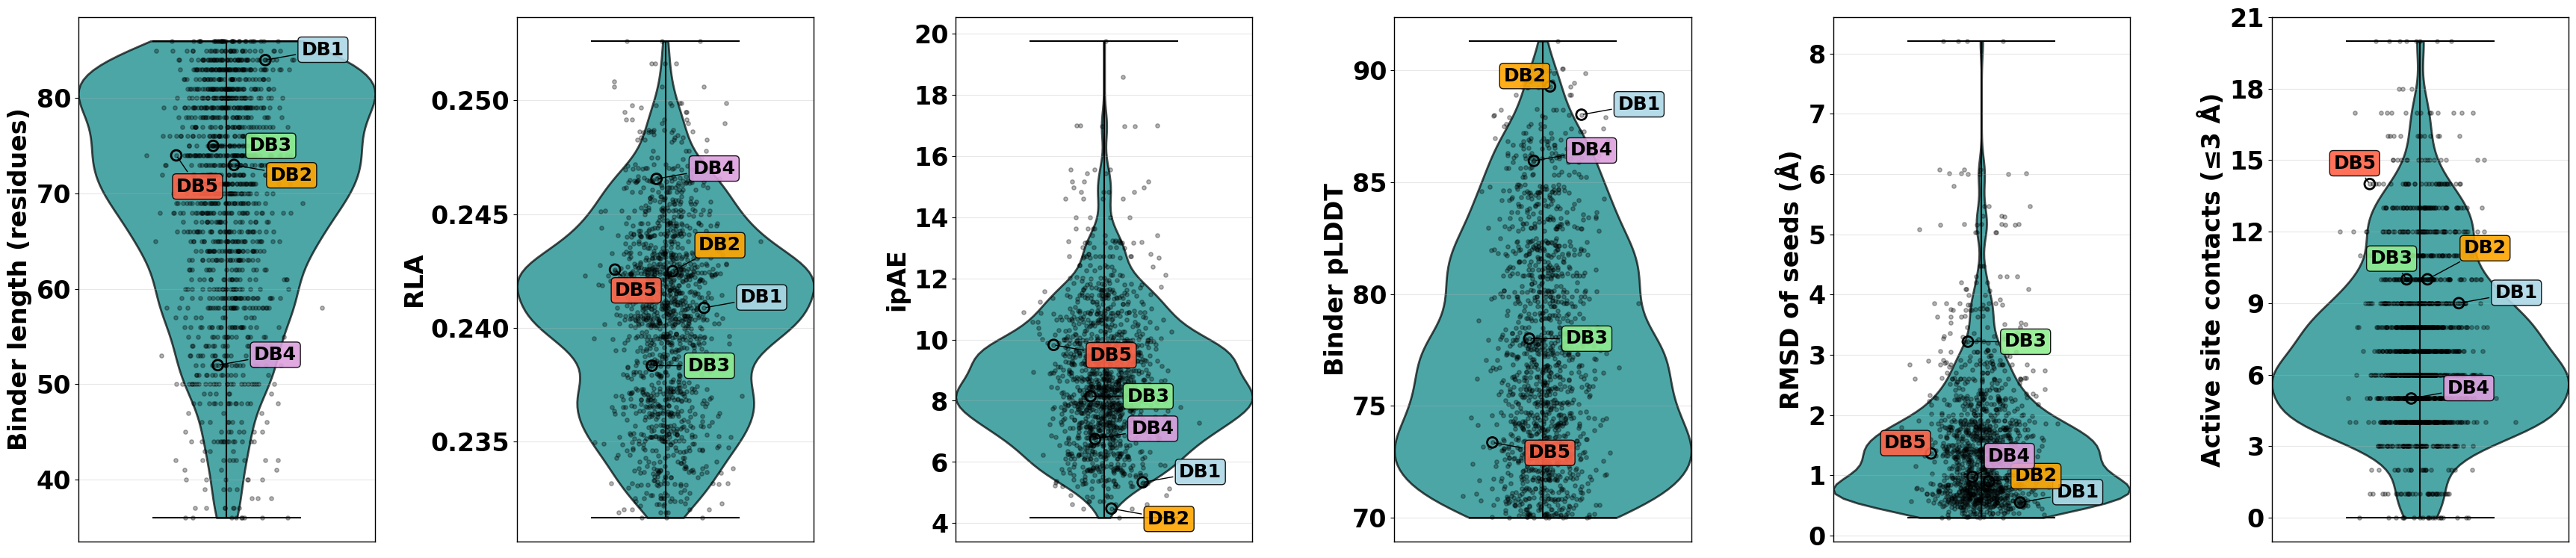

✓ violin_plots_merged_library_2.png


In [13]:
# Median-fill missing values for the two metrics with sparse coverage
analysis_data = enriched_df.copy()
analysis_data['RMSD_NonDesignable_filled'] = (
    analysis_data['RMSD_NonDesignable'].fillna(analysis_data['RMSD_NonDesignable'].median())
    if 'RMSD_NonDesignable' in analysis_data.columns else np.nan
)
analysis_data['RLA_filled'] = (
    analysis_data['RLA_score'].fillna(analysis_data['RLA_score'].median())
    if 'RLA_score' in analysis_data.columns else np.nan
)

# Manual label positions, indexed by axis index (0–5) and DB label
manual_label_positions = {
    0: {  # Binder Length
        'DB1': {'x_offset': 35, 'y_offset':  10},
        'DB2': {'x_offset': 35, 'y_offset': -10},
        'DB3': {'x_offset': 35, 'y_offset':   0},
        'DB4': {'x_offset': 35, 'y_offset':  10},
        'DB5': {'x_offset':  0, 'y_offset': -30},
    },
    1: {  # RLA
        'DB1': {'x_offset': 35, 'y_offset':  10},
        'DB2': {'x_offset': 25, 'y_offset':  25},
        'DB3': {'x_offset': 35, 'y_offset':   0},
        'DB4': {'x_offset': 35, 'y_offset':  10},
        'DB5': {'x_offset':  0, 'y_offset': -20},
    },
    2: {  # ipAE
        'DB1': {'x_offset': 35, 'y_offset':  10},
        'DB2': {'x_offset': 35, 'y_offset': -10},
        'DB3': {'x_offset': 35, 'y_offset':   0},
        'DB4': {'x_offset': 35, 'y_offset':  10},
        'DB5': {'x_offset': 35, 'y_offset': -10},
    },
    3: {  # pLDDT
        'DB1': {'x_offset':  35, 'y_offset':  10},
        'DB2': {'x_offset': -45, 'y_offset':  10},
        'DB3': {'x_offset':  35, 'y_offset':   0},
        'DB4': {'x_offset':  35, 'y_offset':  10},
        'DB5': {'x_offset':  35, 'y_offset': -10},
    },
    4: {  # Seed RMSD
        'DB1': {'x_offset':  35, 'y_offset':  10},
        'DB2': {'x_offset':  25, 'y_offset':   5},
        'DB3': {'x_offset':  35, 'y_offset':   0},
        'DB4': {'x_offset':  15, 'y_offset':  20},
        'DB5': {'x_offset': -45, 'y_offset':  10},
    },
    5: {  # Specific Contacts
        'DB1': {'x_offset':  35, 'y_offset':  10},
        'DB2': {'x_offset':  35, 'y_offset':  30},
        'DB3': {'x_offset': -35, 'y_offset':  20},
        'DB4': {'x_offset':  35, 'y_offset':  10},
        'DB5': {'x_offset': -35, 'y_offset':  20},
    },
}

# (column, title, ylabel, axis index)
metric_info = [
    ('Protein_Length',             'Binder Length',     'Binder length (residues)',     0),
    ('RLA_filled',                 'RLA',               'RLA',                          1),
    ('pae_interaction',            'ipAE',              'ipAE',                         2),
    ('plddt_binder',               'pLDDT',             'Binder pLDDT',                 3),
    ('RMSD_NonDesignable_filled',  'Seed RMSD',         'RMSD of seeds (Å)',        4),
    ('specific_contacts',          'Specific Contacts', 'Active site contacts (≤3 Å)', 5),
]

target_normalized = [normalize_for_matching(t) for t in TARGET_STRUCTURES]
violin_color = 'teal'   # all panels share one color

plt.rcParams.update({
    'font.size':       24,
    'font.weight':     'bold',
    'axes.labelsize':  24,
    'axes.titlesize':  24,
    'xtick.labelsize': 24,
    'ytick.labelsize': 24,
})

fig, axes = plt.subplots(1, 6, figsize=(35, 8))

for column, title, ylabel, ax_idx in metric_info:
    ax = axes[ax_idx]

    if column not in analysis_data.columns:
        ax.text(0.5, 0.5, f'{column}\nNot Found',
                ha='center', va='center', transform=ax.transAxes, fontsize=24)
        ax.set_title(title, fontweight='bold', fontsize=24)
        continue

    metric_data = analysis_data[analysis_data[column].notna()].copy()
    data = metric_data[column]
    if len(data) == 0:
        ax.text(0.5, 0.5, f'No {title}\nData Available',
                ha='center', va='center', transform=ax.transAxes, fontsize=24)
        ax.set_title(title, fontweight='bold', fontsize=24)
        continue

    # Violin
    parts = ax.violinplot([data], positions=[0], widths=0.6,
                          showmeans=False, showmedians=False, showextrema=True)
    for pc in parts['bodies']:
        pc.set_facecolor(violin_color); pc.set_alpha(0.7)
        pc.set_edgecolor('black');      pc.set_linewidth(2)
    parts['cbars'].set_color('black')
    parts['cmaxes'].set_color('black')
    parts['cmins'].set_color('black')

    # Jittered all-data points
    np.random.seed(42)
    jitter = np.random.normal(0, 0.05, len(data))
    ax.scatter(jitter, data, alpha=0.3, s=15, color='black', zorder=1)

    # DB1–DB5 highlights
    metric_data_reset = metric_data.reset_index(drop=True)
    for target_norm, label in zip(target_normalized, TARGET_LABELS):
        matches = metric_data_reset[metric_data_reset['normalized_name'] == target_norm]
        if len(matches) == 0:
            continue
        target_v = matches.iloc[0][column]
        data_idx = matches.index[0]
        if data_idx >= len(jitter):
            continue
        pos = jitter[data_idx]

        ax.scatter([pos], [target_v], s=100, facecolors='none',
                   edgecolors='black', linewidths=2, alpha=1.0, zorder=3)

        offsets = manual_label_positions.get(ax_idx, {}).get(label, {'x_offset': 35, 'y_offset': 0})
        ax.annotate(
            label, (pos, target_v),
            xytext=(offsets['x_offset'], offsets['y_offset']),
            textcoords='offset points',
            fontsize=18, fontweight='bold', ha='left', va='center',
            bbox=dict(boxstyle='round,pad=0.2',
                      facecolor=TARGET_COLORS[label], edgecolor='black', alpha=0.9),
            arrowprops=dict(arrowstyle='-', color='black', lw=1),
            zorder=4,
        )

    ax.set_xlim(-0.3, 0.3)
    ax.set_ylabel(ylabel, fontweight='bold', fontsize=24)
    ax.grid(True, alpha=0.3, axis='y')

    if ax_idx == 5:    # Specific Contacts → integer y-ticks
        ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

# Clean up x-axis
for ax in axes:
    ax.set_xticks([])
    for spine in ax.spines.values():
        spine.set_linewidth(1.0)

plt.tight_layout()
plt.savefig('violin_plots_merged_library_2.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ violin_plots_merged_library_2.png")


## 3. Enrichment histograms

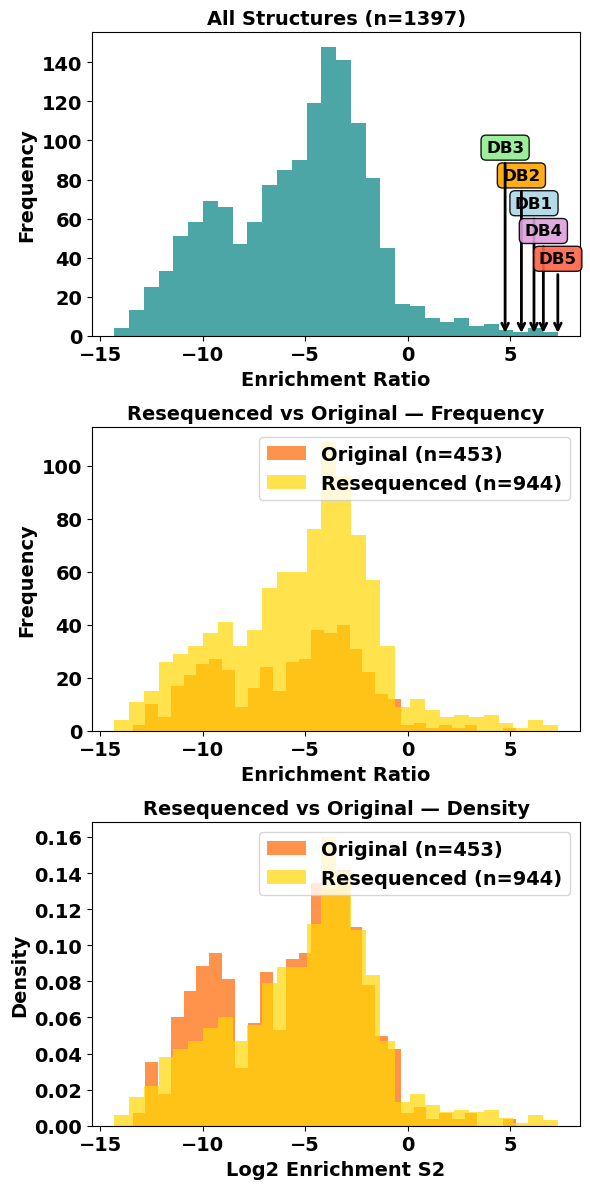

✓ enrichment_histograms_2.png

Summary Statistics

All Structures:
  Mean:    -5.38
  Median:  -4.82
  Std Dev: 3.62
  Min:     -14.32
  Max:     7.32

Original:
  Mean:    -5.79
  Median:  -5.11
  Std Dev: 3.44
  Min:     -13.43
  Max:     5.27

Resequenced:
  Mean:    -5.19
  Median:  -4.65
  Std Dev: 3.69
  Min:     -14.32
  Max:     7.32

T-test (Resequenced vs Original):
  t = 2.919,  p = 0.0036
  ✓ Significant (p < 0.05)


In [14]:
# Reset rcParams (the violin cell mutated them globally)
plt.rcParams.update(plt.rcParamsDefault)

reseq_df    = enriched_df[enriched_df['is_resequenced']]
original_df = enriched_df[~enriched_df['is_resequenced']]

reseq_color    = "gold"
original_color = "#FF6600"
all_color      = "teal"

# Manual positions for DB labels in the all-structures panel
hist_label_positions = {
    'DB1': {'x_offset': 0, 'y_offset':  90},
    'DB2': {'x_offset': 0, 'y_offset': 110},
    'DB3': {'x_offset': 0, 'y_offset': 130},
    'DB4': {'x_offset': 0, 'y_offset':  70},
    'DB5': {'x_offset': 0, 'y_offset':  50},
}

target_normalized = [normalize_for_matching(t) for t in TARGET_STRUCTURES]


def bold_axis(ax, fontsize=14):
    """Make tick labels bold and apply a uniform fontsize."""
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')
        label.set_fontsize(fontsize)


fig, axes = plt.subplots(nrows=3, figsize=(6, 12))

# ── Panel 1: all enriched structures, frequency ────────────────────────────
ax1 = axes[0]
all_data = enriched_df['Log2_Enrichment_S2'].dropna()
ax1.hist(all_data, bins=30, alpha=0.7, color=all_color, edgecolor='none')
ax1.set_xlabel('Enrichment Ratio', fontweight='bold', color='black', fontsize=14)
ax1.set_ylabel('Frequency',        fontweight='bold', color='black', fontsize=14)
ax1.set_title(f'All Structures (n={len(all_data)})',
              fontweight='bold', color='black', fontsize=14)
ax1.grid(False); bold_axis(ax1)

# DB1–DB5 callouts on panel 1
for target_norm, label in zip(target_normalized, TARGET_LABELS):
    target_match = enriched_df[enriched_df['normalized_name'] == target_norm]
    if len(target_match) == 0:
        continue
    target_value = target_match.iloc[0]['Log2_Enrichment_S2']
    offsets = hist_label_positions.get(label, {'x_offset': 0, 'y_offset': 50})
    ax1.annotate(
        label, xy=(target_value, 0),
        xytext=(offsets['x_offset'], offsets['y_offset']),
        textcoords='offset points',
        fontsize=12, fontweight='bold', ha='center', va='bottom',
        bbox=dict(boxstyle='round,pad=0.3',
                  facecolor=TARGET_COLORS[label], edgecolor='black', alpha=0.9),
        arrowprops=dict(arrowstyle='->', color='black', lw=2),
    )

# ── Panel 2: resequenced vs original, frequency ────────────────────────────
ax2 = axes[1]
original_data = original_df['Log2_Enrichment_S2'].dropna() if len(original_df) else None
reseq_data    = reseq_df['Log2_Enrichment_S2'].dropna()    if len(reseq_df)    else None

if original_data is not None and len(original_data):
    ax2.hist(original_data, bins=30, alpha=0.7, color=original_color,
             label=f'Original (n={len(original_data)})', edgecolor='none')
if reseq_data is not None and len(reseq_data):
    ax2.hist(reseq_data, bins=30, alpha=0.7, color=reseq_color,
             label=f'Resequenced (n={len(reseq_data)})', edgecolor='none')

ax2.set_xlabel('Enrichment Ratio', fontweight='bold', color='black', fontsize=14)
ax2.set_ylabel('Frequency',        fontweight='bold', color='black', fontsize=14)
ax2.set_title('Resequenced vs Original — Frequency',
              fontweight='bold', color='black', fontsize=14)
ax2.legend(prop={'weight': 'bold', 'size': 14})
ax2.grid(False); bold_axis(ax2)

# ── Panel 3: resequenced vs original, density ──────────────────────────────
ax3 = axes[2]
if original_data is not None and len(original_data):
    ax3.hist(original_data, bins=30, alpha=0.7, color=original_color,
             density=True, label=f'Original (n={len(original_data)})', edgecolor='none')
if reseq_data is not None and len(reseq_data):
    ax3.hist(reseq_data, bins=30, alpha=0.7, color=reseq_color,
             density=True, label=f'Resequenced (n={len(reseq_data)})', edgecolor='none')

ax3.set_xlabel('Log2 Enrichment S2', fontweight='bold', color='black', fontsize=14)
ax3.set_ylabel('Density',             fontweight='bold', color='black', fontsize=14)
ax3.set_title('Resequenced vs Original — Density',
              fontweight='bold', color='black', fontsize=14)
ax3.legend(prop={'weight': 'bold', 'size': 14})
ax3.grid(False); bold_axis(ax3)

plt.tight_layout()
plt.savefig('enrichment_histograms_2.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ enrichment_histograms_2.png")

# ── Summary statistics ─────────────────────────────────────────────────────
print("\n" + "=" * 60); print("Summary Statistics"); print("=" * 60)

def _print_stats(name, series):
    print(f"\n{name}:")
    print(f"  Mean:    {series.mean():.2f}")
    print(f"  Median:  {series.median():.2f}")
    print(f"  Std Dev: {series.std():.2f}")
    print(f"  Min:     {series.min():.2f}")
    print(f"  Max:     {series.max():.2f}")

_print_stats("All Structures", all_data)
if original_data is not None and len(original_data):
    _print_stats("Original", original_data)
if reseq_data is not None and len(reseq_data):
    _print_stats("Resequenced", reseq_data)

if reseq_data is not None and original_data is not None and len(reseq_data) and len(original_data):
    t_stat, p_value = ttest_ind(reseq_data, original_data)
    print(f"\nT-test (Resequenced vs Original):")
    print(f"  t = {t_stat:.3f},  p = {p_value:.4f}")
    print(f"  {'✓ Significant (p < 0.05)' if p_value < 0.05 else 'No significant difference (p ≥ 0.05)'}")
